In [39]:
using CoolProp
using Statistics, DataFrames, GLM, StatsModels, Plots

In [ ]:
# Pressure (Pa) and temperature (K) ranges
P_vals = collect(100e5:0.5e5:300e5)
T_vals = collect(273:1:293)

# 2D matrix: rows = P_vals, columns = T_vals
isobaric_expansion_coefficient_vals = [PropsSI("isobaric_expansion_coefficient", "T", T, "P", P, "CO2") for P in P_vals, T in T_vals] # Isobaric expansion coefficient in 1/K

# Example: isobaric_expansion_coefficient_vals[i, j] corresponds to P_vals[i], T_vals[j]
# vec() flattens column-major, so P must vary fastest (outer) and T slowest (inner)
df = DataFrame(
    P = repeat(P_vals, outer=length(T_vals)),
    T = repeat(T_vals, inner=length(P_vals)),
    y = vec(isobaric_expansion_coefficient_vals)
)

Row,P,T,y
,Float64,Int64,Float64
1,1.0e7,273,0.00510771
2,1.005e7,273,0.00509772
3,1.01e7,273,0.00508778
4,1.015e7,273,0.0050779
5,1.02e7,273,0.00506808
6,1.025e7,273,0.00505832
7,1.03e7,273,0.00504861
8,1.035e7,273,0.00503896
9,1.04e7,273,0.00502937


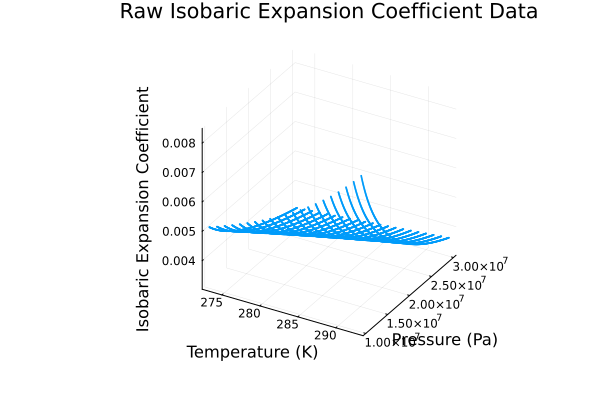

In [41]:
# Raw data plot as a 3D scatter: each point is one (T, P, y) sample
T_grid = repeat(T_vals, inner=length(P_vals))
P_grid = repeat(P_vals, outer=length(T_vals))

scatter(
    T_grid,
    P_grid,
    vec(isobaric_expansion_coefficient_vals),
    xlabel = "Temperature (K)",
    ylabel = "Pressure (Pa)",
    zlabel = "Isobaric Expansion Coefficient",
    title = "Raw Isobaric Expansion Coefficient Data",
    markersize = 1,
    markerstrokewidth = 0,
    legend = false
 )

In [42]:
# Fit Model 

df.Ps = df.P/1e5
df.Ts = df.T

model = lm(@formula(y ~ 1 + Ps + Ts + Ps^2 + Ts^2 + Ps&Ts + Ps^3 + Ts^3), df)

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

y ~ 1 + Ps + Ts + :(Ps ^ 2) + :(Ts ^ 2) + :(Ps ^ 3) + :(Ts ^ 3) + Ps & Ts

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                    Coef.     Std. Error        t  Pr(>|t|)      Lower 95%     Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)   0.0          NaN             NaN       NaN     NaN            NaN
Ps            7.62879e-5     1.03263e-6     73.88    <1e-99    7.42637e-5     7.83121e-5
Ts            0.0          NaN             NaN       NaN     NaN            NaN
Ps ^ 2        2.59322e-7     3.70838e-9     69.93    <1e-99    2.52053e-7     2.66592e-7
Ts ^ 2       -1.50452e-7     2.53854e-9    -59.27    <1e-99   -1.55429e-7    -1.45476e-7
Ps ^ 3       -3.27313e-1

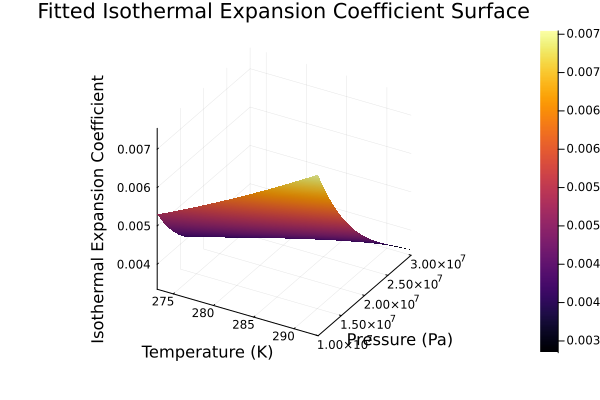

In [43]:
# Predict isothermal expansion coefficient on the same P-T grid used for fitting
# Same column-major ordering as df: P varies fastest, T slowest
pred_df = DataFrame(
    P = repeat(P_vals, outer=length(T_vals)),
    T = repeat(T_vals, inner=length(P_vals))
)

pred_df.Ps = pred_df.P/1e5
pred_df.Ts = pred_df.T

pred_vals = predict(model, pred_df)
pred_surface = reshape(pred_vals, length(P_vals), length(T_vals))

# Surface plot: x = T, y = P, z = predicted isobaric expansion coefficient
surface(
    T_vals,
    P_vals,
    pred_surface,
    xlabel = "Temperature (K)",
    ylabel = "Pressure (Pa)",
    zlabel = "Isothermal Expansion Coefficient",
    title = "Fitted Isothermal Expansion Coefficient Surface",
 )

In [44]:
# Test Model Fit at a specific (T, P) point

coefficients = coef(model)
println("Coefficients: ", coefficients)
T = 300
P = 100e5

y = coefficients[1] + coefficients[2] * (P/1e5) + coefficients[3] * T + coefficients[4] * (P/1e5)^2 + coefficients[5] * T^2 + coefficients[6] * (P/1e5)^3 + coefficients[7] * T^3 + coefficients[8] * (P/1e5)*T 
println("Predicted isobaric expansion coefficient at T = ", T, " K and P = ", P, " Pa: ", y, " 1/K")
println("Actual isobaric expansion coefficient at T = ", T, " K and P = ", P, " Pa: ", PropsSI("isobaric_expansion_coefficient", "T", 300, "P", 100e5, "CO2"), " 1/K")

Coefficients: [0.0, 7.628790172252159e-5, 0.0, 2.593223862806059e-7, -1.5045239389591395e-7, -3.2731323337965117e-10, 1.047334922122834e-9, -5.385394624657962e-7]
Predicted isobaric expansion coefficient at T = 300 K and P = 1.0e7 Pa: 0.008475844374388943 1/K
Actual isobaric expansion coefficient at T = 300 K and P = 1.0e7 Pa: 0.011172776926794609 1/K


In [45]:
println("\n===== FIT QUALITY (corrected data) =====")
r = residuals(model); yh = predict(model)
relerr = abs.(r) ./ df.y
println("R2                 = ", round(r2(model), digits=6))
println("adj R2             = ", round(adjr2(model), digits=6))
println("RMSE               = ", round(sqrt(mean(r.^2)), sigdigits=4))
println("y range            = ", round.(extrema(df.y), sigdigits=4))
println("y std              = ", round(std(df.y), sigdigits=4))
println("max |rel error|    = ", round(100*maximum(relerr), digits=3), " %")
println("mean |rel error|   = ", round(100*mean(relerr), digits=3), " %")




===== FIT QUALITY (corrected data) =====
R2                 = 0.991072
adj R2             = 0.991067
RMSE               = 8.618e-5
y range            = (0.003184, 0.008347)
y std              = 0.0009122
max |rel error|    = 9.621 %
mean |rel error|   = 1.334 %
